In [86]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import XGate, RYGate
from qiskit.quantum_info import partial_trace
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [87]:
def lap1d_fd(n, h=1.0, bc="dirichlet"):
    """
    Build 1D second-order finite-difference  (standard 3-point centered (central) finite-difference discretization for the second derivative) 
    Laplacian for `n` grid points with spacing `h` and boundary condition `bc`.

    Parameters
    ----------
    n : int
        Number of grid points (nodes) along the 1D domain (>=1).
    h : float
        Grid spacing.
    bc : {'dirichlet','neumann','periodic'}
        Boundary condition type:
          - 'dirichlet' : u=0 at boundaries (standard tridiagonal).
          - 'neumann'   : zero-flux (one-sided treatment at endpoints).
          - 'periodic'  : wrap-around neighbors (circulant/tridiagonal with corners).

    Returns
    -------
    A : scipy.sparse.csr_matrix, shape (n,n)
        Sparse 1D Laplacian matrix (second derivative approximation) scaled by 1/h^2.
    """
    if n < 1:
        raise ValueError("n must be >= 1")

    main = -2.0 / (h * h)
    off = 1.0 / (h * h)

    # tridiagonal base (LIL for easy element assignment)
    A = sp.diags(
        [off * np.ones(n - 1), main * np.ones(n), off * np.ones(n - 1)],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="lil",
    )

    if bc == "periodic":
        # wrap-around entries
        if n >= 2:
            A[0, n - 1] = off
            A[n - 1, 0] = off
        else:
            # n == 1: Laplacian on single periodic point is zero
            A[0, 0] = 0.0

    elif bc == "neumann":
        # zero-flux (reflect ghost): use one-sided second-derivative approx
        if n == 1:
            A[0, 0] = 0.0
        else:
            # first row: (-2 u0 + 2 u1)/h^2
            A[0, 0] = -2.0 / (h * h)
            A[0, 1] = 2.0 / (h * h)
            # last row symmetric
            A[n - 1, n - 1] = -2.0 / (h * h)
            A[n - 1, n - 2] = 2.0 / (h * h)

    else:
        # Dirichlet: standard tridiagonal (rows kept as is).
        pass

    return A.tocsr()


def generate_laplacian(shape, deltas=None, bcs=None, analytic_normalize=False):
    """
    Build separable FD Laplacian and optionally apply analytic normalization ().

    Parameters
    ----------
    shape : tuple of ints
        Number of grid points per axis (Nx, Ny, ...).
    deltas : tuple of floats or None
        Grid spacings per axis (hx, hy, ...). If None, uses 1.0 for each axis.
    bcs : str or tuple-of-str or None
        Boundary conditions per axis. If None, uses 'dirichlet' on all axes.
    analytic_normalize : bool
        If True, scale the assembled Laplacian by lambda_max = 4 * sum_i (1/h_i^2). 
        Returns (A_scaled, lambda_max). If False, returns A only. (We use the same analytical scaling factor as in the Sturm et al. 2025 paper.)

    Returns
    -------
    A or A_scaled
    """

    shape = tuple(shape)
    D = len(shape)
    if deltas is None:
        deltas = tuple([1.0] * D)
    else:
        deltas = tuple(deltas)

    if bcs is None:
        bcs = tuple(["dirichlet"] * D)
    elif isinstance(bcs, str):
        bcs = tuple([bcs] * D)
    else:
        bcs = tuple(bcs)

    # Build 1D operators
    ops_1d = [lap1d_fd(n, h, bc) for (n, h, bc) in zip(shape, deltas, bcs)]

    # Build Kronecker-sum: sum_k (I ⊗ ... ⊗ K_k ⊗ ... ⊗ I) # just like in the third reference paper (Sturm et al. 2015)
    total = None
    for axis, K in enumerate(ops_1d):
        # left identity: product of identity matrices for axes > axis
        kron_left = sp.eye(1, format="csr")
        for j in range(D - 1, axis, -1):
            kron_left = sp.kron(sp.eye(shape[j], format="csr"), kron_left, format="csr")

        # right identity: product for axes < axis
        kron_right = sp.eye(1, format="csr")
        for j in range(0, axis):
            kron_right = sp.kron(kron_right, sp.eye(shape[j], format="csr"), format="csr")

        term = sp.kron(kron_left, sp.kron(K, kron_right, format="csr"), format="csr")
        total = term if total is None else (total + term)

    A = total.tocsr()

    if analytic_normalize:  # again the same scaling factor as in the Sturm et al. 2025 paper
        # analytic lambda_max = 4 * sum_i (1 / h_i^2)
        lambda_max = 4.0 * sum((1.0 / (h * h)) for h in deltas)
        if lambda_max <= 0:
            raise ValueError("Computed lambda_max <= 0; check grid spacings.")
        A_scaled = A / lambda_max
        return A_scaled.tocsr()
    else:
        return A
    

matrix = generate_laplacian((2**3,), None, ("dirichlet",), True)
print(matrix.todense())

[[-0.5   0.25  0.    0.    0.    0.    0.    0.  ]
 [ 0.25 -0.5   0.25  0.    0.    0.    0.    0.  ]
 [ 0.    0.25 -0.5   0.25  0.    0.    0.    0.  ]
 [ 0.    0.    0.25 -0.5   0.25  0.    0.    0.  ]
 [ 0.    0.    0.    0.25 -0.5   0.25  0.    0.  ]
 [ 0.    0.    0.    0.    0.25 -0.5   0.25  0.  ]
 [ 0.    0.    0.    0.    0.    0.25 -0.5   0.25]
 [ 0.    0.    0.    0.    0.    0.    0.25 -0.5 ]]


In [88]:
rows, cols = matrix.nonzero()
vals = matrix.data

In [89]:
data = QuantumRegister(1, "data")
l = QuantumRegister(2, "l")
j = QuantumRegister(3, "j")
simulator = AerSimulator(method="unitary")

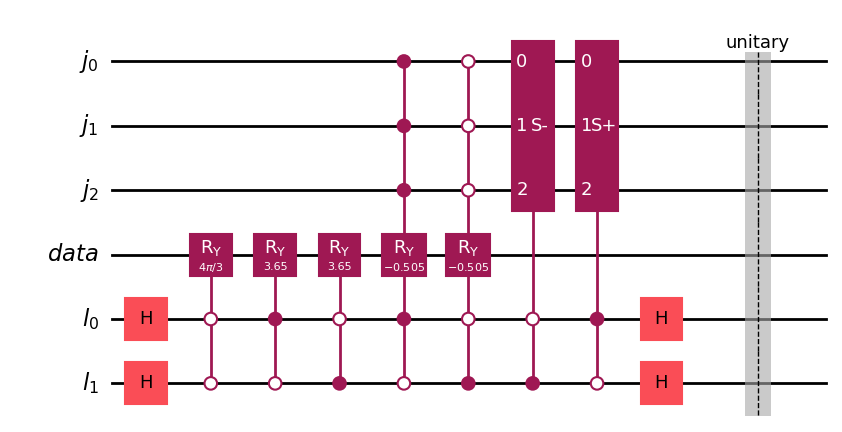

In [142]:
qc = QuantumCircuit(j, data, l)
diag = 2 * np.arccos(0.5 - 1)
off = 2 * np.arccos(-0.25)

csdown = ShiftDown(3).control(2, ctrl_state=2)
csup = ShiftUp(3).control(2, ctrl_state=1)
cry0 = RYGate(diag).control(2, ctrl_state=0)
cry1 = RYGate(off).control(2, ctrl_state=1)
cry2 = RYGate(off).control(2, ctrl_state=2)

dirichlet_correction0 = RYGate(np.pi - off).control(5, ctrl_state="11101")
dirichlet_correction1 = RYGate(np.pi - off).control(5, ctrl_state="00010")


qc.h(l)
qc.append(cry0, l[:] + data[:])
qc.append(cry1, l[:] + data[:])
qc.append(cry2, l[:] + data[:])
qc.append(dirichlet_correction0, l[:] + j[:] + data[:])
qc.append(dirichlet_correction1, l[:] + j[:] + data[:])
qc.append(csdown, l[:] + j[:])
qc.append(csup, l[:] + j[:])
# qc.cy(l[0], data[0])

qc.h(l)

qc.save_unitary()
qc.draw(output="mpl")

In [143]:
qc = transpile(qc, simulator)

result = simulator.run(qc).result()
unitary = result.get_unitary(qc).data

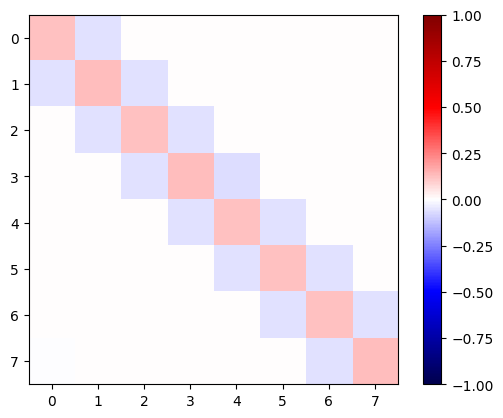

In [153]:
plt.imshow(unitary[:8, :8].real, vmin=-1, vmax=1, cmap="seismic")
plt.colorbar()